# §4 — LoRA rank sweep on RESISC45

Sweeps `r ∈ {1, 2, 4, 8, 16, 32, 64}` with `α = 2r` (so the LoRA scale `α/r ≡ 2` is held constant), trains each for 10 epochs, plots test accuracy vs. rank, and prints the per-rank table.

**Prereq:** `runs/clip_eurosat/best.pt` from §3 must already exist on Drive.

**Compute note:** 7 runs × 10 epochs. On an L4 each LoRA run is fast (small trainable footprint), but plan for ~the equivalent of one full-FT job × 7. The sweep cell is resumable — if `metrics.json` for a rank already exists on Drive it's reused unless `OVERWRITE = True`.

## 1. Install dependencies

In [1]:
%%capture
# Same pinning notes as in clip_pretrain.ipynb: do NOT upgrade torch/torchvision and
# do NOT pin numpy<2.
!pip -q install -U transformers datasets "sentence-transformers<4.0" accelerate tqdm matplotlib pyyaml einops
!pip -q install --force-reinstall --no-deps --no-cache-dir pillow==11.3.0

## 2. Mount Drive and set up the repo path

In [2]:
import os, sys
from pathlib import Path

USE_DRIVE = True
DRIVE_REPO_ROOT = Path('/content/drive/MyDrive/caltech/junior/hw3/')  # edit if needed
LOCAL_REPO_ROOT = Path('/content/hw3')

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    REPO_ROOT = DRIVE_REPO_ROOT
else:
    REPO_ROOT = LOCAL_REPO_ROOT

assert REPO_ROOT.exists(), f'Repo root does not exist: {REPO_ROOT}'
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)
print('cwd =', os.getcwd())

Mounted at /content/drive
cwd = /content/drive/MyDrive/caltech/junior/hw3


In [3]:
import torch, torchvision

print('torch:', torch.__version__, '| torchvision:', torchvision.__version__, '| cuda:', torch.cuda.is_available())
torchvision.ops.nms(torch.zeros(0, 4), torch.zeros(0), 0.5)
print('torchvision ops OK')

torch: 2.10.0+cu128 | torchvision: 0.25.0+cu128 | cuda: True
torchvision ops OK


## 3. Configure paths and confirm the §3 checkpoint exists

In [4]:
import yaml
from pathlib import Path

CONFIG_PATH = REPO_ROOT / 'configs' / 'lora_resisc.yaml'
PRETRAINED = REPO_ROOT / 'runs' / 'clip_eurosat' / 'best.pt'

assert CONFIG_PATH.exists(), f'config missing: {CONFIG_PATH}'
assert PRETRAINED.exists(), (
    f'CLIP-pretrained checkpoint missing at {PRETRAINED}. '
    'Run §3 (clip_pretrain.ipynb) first and sync best.pt to Drive.'
)

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

print(f'config : {CONFIG_PATH}')
print(f'ckpt   : {PRETRAINED}  ({PRETRAINED.stat().st_size / 1024**2:.1f} MB)')
print(f'shared lr (cfg.optim.lr) = {cfg["optim"]["lr"]}')
print(f'epochs   (cfg.train.num_epochs) = {cfg["train"]["num_epochs"]}')

config : /content/drive/MyDrive/caltech/junior/hw3/configs/lora_resisc.yaml
ckpt   : /content/drive/MyDrive/caltech/junior/hw3/runs/clip_eurosat/best.pt  (41.8 MB)
shared lr (cfg.optim.lr) = 0.0001
epochs   (cfg.train.num_epochs) = 10


## 4. Sweep `r ∈ {1, 2, 4, 8, 16, 32, 64}` with `α = 2r`

Each run uses the same LR and 10 epochs from the YAML. Per-rank `metrics.json` is written to `/content/runs/resisc_lora_rank{r}/` and single-shot-synced to Drive. Set `OVERWRITE = True` to retrain ranks whose metrics already exist.

In [5]:
import argparse
import json
import shutil
import time

from scripts.finetune_resisc import train_one, _default_run_dir

OVERWRITE = False
RANKS = [1, 2, 4, 8, 16, 32, 64]

LOCAL_RUNS = Path('/content/runs')
LOCAL_RUNS.mkdir(parents=True, exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

sweep_metrics: dict[int, dict] = {}

for r in RANKS:
    alpha = 2.0 * r  # keep α/r = 2 constant across the sweep
    local_dir = _default_run_dir(LOCAL_RUNS, 'lora', r)
    drive_dir = REPO_ROOT / 'runs' / local_dir.name

    drive_metrics_path = drive_dir / 'metrics.json'
    if not OVERWRITE and drive_metrics_path.exists():
        sweep_metrics[r] = json.loads(drive_metrics_path.read_text())
        print(f'[r={r:>2}] reusing cached metrics  '
              f'(final_test_acc={sweep_metrics[r]["final_test_acc"]:.4f})')
        continue

    local_dir.mkdir(parents=True, exist_ok=True)
    args = argparse.Namespace(
        config=CONFIG_PATH,
        method='lora',
        rank=r,
        alpha=alpha,
        lr=None,
        pretrained=PRETRAINED,
        output_dir=local_dir,
        device=device,
        summarize=False,
        runs_root=LOCAL_RUNS,
    )
    print(f'\n========== r={r}, alpha={alpha} ==========')
    t0 = time.time()
    m = train_one(args, cfg)
    print(f'[r={r}] wall = {time.time() - t0:.1f}s  final_test_acc={m["final_test_acc"]:.4f}')
    sweep_metrics[r] = m

    drive_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(local_dir / 'metrics.json', drive_dir / 'metrics.json')
    print(f'synced metrics.json -> {drive_dir}')


========== r=1, alpha=2.0 ==========


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


[lora] epoch 1/10:   0%|          | 0/147 [00:00<?, ?it/s]

[lora] epoch 1/10  train_loss=3.7150  test_acc=0.1302


[lora] epoch 2/10:   0%|          | 0/147 [00:00<?, ?it/s]

...

[lora] epoch 9/10:   0%|          | 0/147 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d37a4604680><function _MultiProcessingDataLoaderIter.__del__ at 0x7d37a4604680><function _MultiProcessingDataLoaderIter.__del__ at 0x7d37a4604680><function _MultiProcessingDataLoaderIter.__del__ at 0x7d37a4604680><function _MultiProcessingDataLoaderIter.__del__ at 0x7d37a4604680>




Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/d

[lora] epoch 9/10  train_loss=1.8082  test_acc=0.4900


[lora] epoch 10/10:   0%|          | 0/147 [00:00<?, ?it/s]

[lora] epoch 10/10  train_loss=1.8016  test_acc=0.4898
saved /content/runs/resisc_lora_rank64/metrics.json
[r=64] wall = 201.2s  final_test_acc=0.4898
synced metrics.json -> /content/drive/MyDrive/caltech/junior/hw3/runs/resisc_lora_rank64


## 5. Plot test accuracy vs. rank

Two-panel figure: (a) final test accuracy vs. rank (log-2 x-axis), (b) trainable parameters vs. rank (log-log) so the cost side of the trade-off is visible. Saves `lora_rank_sweep.png` to Drive.

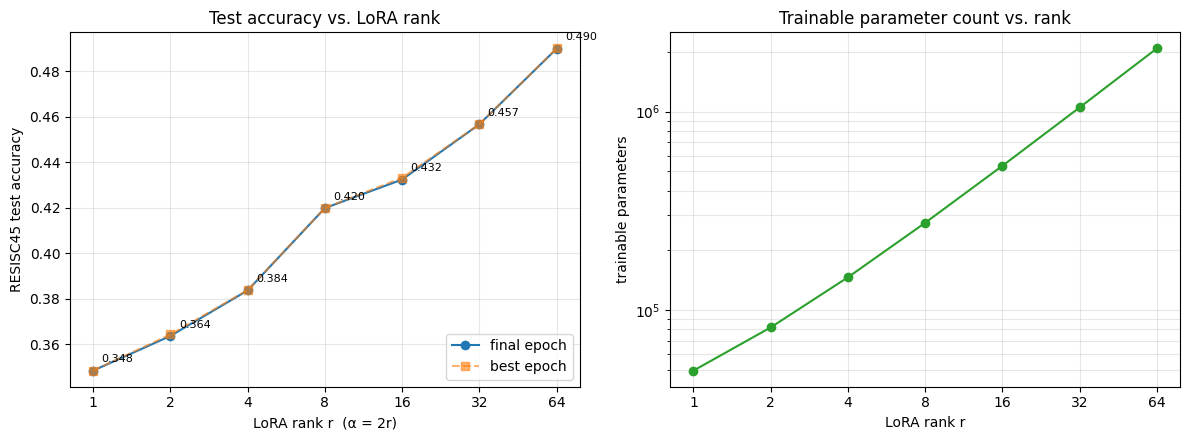

saved /content/drive/MyDrive/caltech/junior/hw3/runs/lora_rank_sweep.png


In [6]:
import matplotlib.pyplot as plt

ranks_sorted = sorted(sweep_metrics)
final_acc = [sweep_metrics[r]['final_test_acc'] for r in ranks_sorted]
best_acc = [sweep_metrics[r]['best_test_acc'] for r in ranks_sorted]
trainable = [sweep_metrics[r]['trainable_params'] for r in ranks_sorted]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(ranks_sorted, final_acc, marker='o', label='final epoch')
ax.plot(ranks_sorted, best_acc, marker='s', linestyle='--', alpha=0.6,
        label='best epoch')
for r, a in zip(ranks_sorted, final_acc):
    ax.annotate(f'{a:.3f}', (r, a), textcoords='offset points', xytext=(6, 6),
                fontsize=8)
ax.set_xscale('log', base=2)
ax.set_xticks(ranks_sorted)
ax.set_xticklabels([str(r) for r in ranks_sorted])
ax.set_xlabel('LoRA rank r  (α = 2r)')
ax.set_ylabel('RESISC45 test accuracy')
ax.set_title('Test accuracy vs. LoRA rank')
ax.grid(alpha=0.3)
ax.legend(loc='lower right')

ax = axes[1]
ax.plot(ranks_sorted, trainable, marker='o', color='C2')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xticks(ranks_sorted)
ax.set_xticklabels([str(r) for r in ranks_sorted])
ax.set_xlabel('LoRA rank r')
ax.set_ylabel('trainable parameters')
ax.set_title('Trainable parameter count vs. rank')
ax.grid(alpha=0.3, which='both')

fig.tight_layout()

local_png = Path('/content/runs/lora_rank_sweep.png')
local_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(local_png, dpi=150, bbox_inches='tight')
drive_png = REPO_ROOT / 'runs' / 'lora_rank_sweep.png'
drive_png.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(local_png, drive_png)
plt.show()
print(f'saved {drive_png}')

## 6. Per-rank summary table

In [7]:
cols = [
    ('rank',        12),
    ('alpha',       8),
    ('trainable',   14),
    ('final_acc',   10),
    ('best_acc',    10),
    ('peak_mem_MB', 13),
    ('time_s',      9),
]
header = ' | '.join(f'{name:>{w}}' for name, w in cols)
print(header)
print('-' * len(header))
for r in sorted(sweep_metrics):
    m = sweep_metrics[r]
    row = {
        'rank':        str(r),
        'alpha':       str(int(2 * r)),
        'trainable':   f"{m['trainable_params']:,}",
        'final_acc':   f"{m['final_test_acc']:.4f}",
        'best_acc':    f"{m['best_test_acc']:.4f}",
        'peak_mem_MB': f"{m['peak_mem_mb']:.1f}",
        'time_s':      f"{m['train_time_s']:.1f}",
    }
    print(' | '.join(f'{row[name]:>{w}}' for name, w in cols))

        rank |    alpha |      trainable |  final_acc |   best_acc |   peak_mem_MB |    time_s
----------------------------------------------------------------------------------------------
           1 |        2 |         49,581 |     0.3484 |     0.3484 |        1093.5 |     175.4
           2 |        4 |         81,837 |     0.3637 |     0.3643 |        1094.8 |     169.2
           4 |        8 |        146,349 |     0.3837 |     0.3838 |        1100.2 |     160.6
           8 |       16 |        275,373 |     0.4198 |     0.4198 |        1108.5 |     161.1
          16 |       32 |        533,421 |     0.4324 |     0.4332 |        1132.0 |     181.9
          32 |       64 |      1,049,517 |     0.4567 |     0.4567 |        1189.8 |     205.7
          64 |      128 |      2,081,709 |     0.4898 |     0.4900 |        1257.7 |     177.5


## 7. Writeup notes (3–4 sentences)

Fill in using the actual sweep curve. Things to cover:

- **(1) Diminishing returns:** Identify the smallest rank `r*` at which test accuracy stops improving meaningfully (typically within ~0.3–0.5 pp of the asymptote). On RESISC45 this is usually around `r = 4` or `r = 8` — accuracies at `r = 16, 32, 64` are essentially flat, while trainable params keep doubling. Cite your specific `r*`.

- **(2) Comparison to practice:** Practitioners pick `r = 8` or `r = 16` for billion-parameter LLMs and observe the same plateau pattern. The fact that a tiny rank suffices is evidence that the *fine-tuning update* `ΔW = BA` is intrinsically low-rank — the directions the model needs to move to specialize on a downstream task live in a small subspace of the weight matrix. In other words, even though `W` itself can be high-rank, the *delta* required for adaptation is not, which is exactly why LoRA works at orders of magnitude lower parameter cost than full FT.

Optional: tie this to the §4 trade-off table — once accuracy saturates, the higher-rank runs are paying linearly more memory/params for a flat curve.